# Assignment 7

### Using Gemma3:1b via Google Cloud - Vertex AI

#### Steps taken: 
Sign up for free trial

Go to vertex - model garden

Select Gemma 3

Select 1b it, nvidia l4, region

Create endpoint

Install gcloud SDK locally if not already installed

Set up ADC

Get code from documentation using endpoint and project from cloud console

Hit endpoint with prompt, temperature, and max tokens.

In [1]:
import google.auth
creds, proj = google.auth.default()
print("ADC found:", bool(creds), "Project:", proj)

ADC found: True Project: None


In [2]:
# Code Generated by GPT-5 (high reasoning) via Windsurf 10/23/25


# Vertex AI prediction to a Dedicated Endpoint using the high-level SDK.
# Docs:
# - Python SDK index: https://cloud.google.com/python/docs/reference/aiplatform/latest/index.html
# - Predict sample (pattern): https://github.com/googleapis/python-aiplatform/blob/main/samples/snippets/prediction_service/predict_custom_trained_model_sample.py

# If needed:
# %pip install -q google-cloud-aiplatform google-auth

from google.cloud import aiplatform

# Your details
PROJECT_ID = "neural-cirrus-475920-u9"
PROJECT_NUMBER = "115484977435"           # Use the project NUMBER for dedicated endpoints
REGION = "us-east4"
ENDPOINT_ID = "gemma-3-1b-it-mg-one-click-deploy"  # This is your endpoint's ID from Console (string)

# Initialize SDK
aiplatform.init(project=PROJECT_ID, location=REGION)

# Build the endpoint resource path with PROJECT_NUMBER + your string ENDPOINT_ID
endpoint_name = f"projects/{PROJECT_NUMBER}/locations/{REGION}/endpoints/{ENDPOINT_ID}"
endpoint = aiplatform.Endpoint(endpoint_name=endpoint_name)

# Request
instances = [{"prompt": "Write a haiku about sparrows."}]
parameters = {"temperature": 0.2, "max_output_tokens": 256}

# For dedicated endpoints, tell the SDK to use the dedicated domain
response = endpoint.predict(
    instances=instances,
    parameters=parameters,
    use_dedicated_endpoint=True,
)

print("deployed_model_id:", response.deployed_model_id if hasattr(response, "deployed_model_id") else None)
for i, pred in enumerate(response.predictions or [], 1):
    print(f"prediction {i}:", pred)

deployed_model_id: 3614668665569411072
prediction 1: Prompt:
Write a haiku about sparrows.
Output:
Little wings, a flash of grey,
Dancing on the sunlit breeze


### Using Gemma3:1b locally via Ollama and FastAPI

#### Steps Taken

Ensure ollama installed

Create a FastAPI app

Create app methods 

launch uvicorn server to handle the API requests.

create a post request and call model

In [ ]:
# Code Generated by GPT-5 (high reasoning) via Windsurf 10/23/25
# Prompt:  I'd like to use the same model locally (using ollama prefereably) via a REST API using FastAPI

# If needed:
# %pip install -q fastapi uvicorn requests nest_asyncio

import os
import threading
import requests
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import uvicorn
import nest_asyncio

# -------- Config --------
OLLAMA_HOST = os.getenv("OLLAMA_HOST", "http://127.0.0.1:11434")  # default local Ollama
DEFAULT_MODEL = os.getenv("OLLAMA_MODEL", "gemma3:1b")             # change to your local model tag
DEFAULT_PORT = int(os.getenv("PORT", "8000"))

# -------- App --------
app = FastAPI(title="Local LLM API (Ollama)")

class GenerateRequest(BaseModel):
    prompt: str
    model: str | None = None
    temperature: float = 0.2
    max_tokens: int = 256

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/generate")
def generate(req: GenerateRequest):
    model = req.model or DEFAULT_MODEL
    payload = {
        "model": model,
        "prompt": req.prompt,
        "options": {
            "temperature": req.temperature,
            "num_predict": req.max_tokens,
        },
        "stream": False,  # easier handling in an API
    }
    try:
        r = requests.post(f"{OLLAMA_HOST}/api/generate", json=payload, timeout=120)
    except requests.exceptions.RequestException as e:
        raise HTTPException(status_code=502, detail=f"Ollama unreachable: {e}")

    if r.status_code != 200:
        raise HTTPException(status_code=r.status_code, detail=r.text)

    data = r.json()
    return {
        "model": model,
        "output": data.get("response", ""),
        "eval_count": data.get("eval_count"),
        "done": data.get("done", True),
    }

# -------- Launch server in background (Jupyter-friendly) --------
nest_asyncio.apply()

def _run():
    uvicorn.run(app, host="127.0.0.1", port=DEFAULT_PORT, log_level="info")

thread = threading.Thread(target=_run, daemon=True)
thread.start()
print(f"FastAPI server running at http://127.0.0.1:{DEFAULT_PORT}  |  Try POST /generate")

FastAPI server running at http://127.0.0.1:8000  |  Try POST /generate


INFO:     Started server process [31806]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:56927 - "POST /generate HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:56940 - "POST /generate HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:57444 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58227 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58581 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58587 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58593 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58598 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58603 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58608 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58612 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58617 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58622 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58627 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58631 - "POST /generate HTTP/1.1" 200 OK
INFO:     127.0.0.1:58637 - "POST /generate HTTP/1.1" 200 OK
INFO:     

In [8]:
import requests

resp = requests.post(
    "http://127.0.0.1:8000/generate",
    json={
        "prompt": "Tell me a story.",
        "model": "gemma3:1b",       # or set to your local model tag
        "temperature": 0.2,
        "max_tokens": 256,
    },
    timeout=120,
)
print(resp.status_code, resp.reason)
print(resp.json())

200 OK
{'model': 'gemma3:1b', 'output': 'Okay, here’s a story for you. It’s a little bit about a forgotten lighthouse keeper and a lost star.\n\n---\n\nThe salt spray of the North Sea was Silas’s constant companion. For fifty years, he’d tended the North Point Lighthouse, a solitary sentinel perched on a jagged cliff overlooking the churning grey waters. He’d seen storms that swallowed ships whole and sunsets that painted the sky in impossible hues. He’d grown quiet, his face etched with the lines of a life lived in the rhythm of the waves. \n\nOne particularly bleak autumn evening, a storm raged with a ferocity Silas hadn’t witnessed in decades. The wind howled like a banshee, and the waves crashed against the base of the lighthouse with a terrifying roar. As the storm reached its peak, a single, brilliant star, a sapphire shard of light, pierced through the clouds and plummeted towards the sea. \n\nSilas, drawn by an inexplicable pull, climbed the winding stairs to the top. He didn’t

### Comparing the Cloud deployment (Nvidia L4) and Local deployment (Macbook Pro with M3 Pro)

Running cloud (256)...
Running cloud (512)...
Running local (256)...
Running local (512)...

Summary (seconds):
Cloud 256 -> avg: 0.348, min: 0.234, max: 1.765, n=25
Cloud 512 -> avg: 0.245, min: 0.229, max: 0.300, n=25
Local 256 -> avg: 2.767, min: 2.584, max: 3.752, n=25
Local 512 -> avg: 5.369, min: 5.142, max: 5.617, n=25


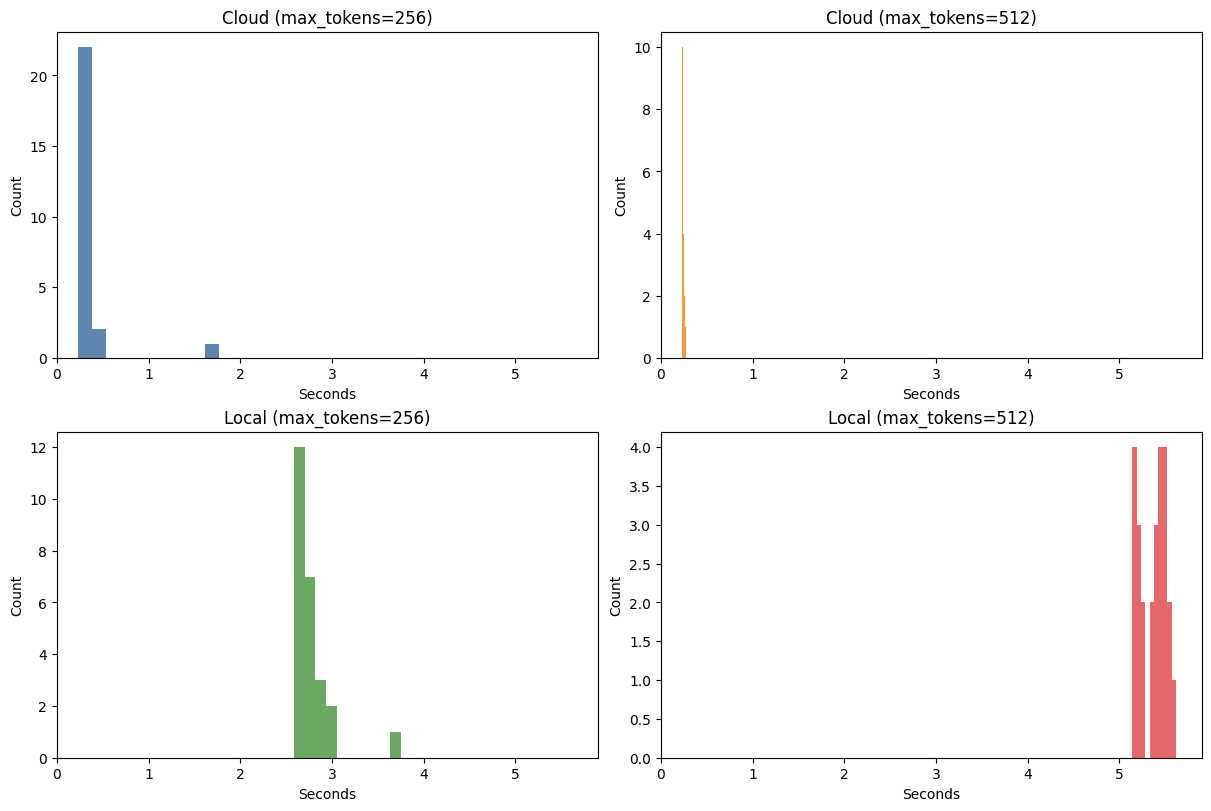

In [ ]:
# Code Generated by GPT-5 (high reasoning) via Windsurf 10/23
# Prompt: Can you generate me code for a cell to compare the performance of 
# these two deployments? Primarily in terms of time taken. I would like the prompt 
# "tell me a story" run 25 times with the max tokens of 256, then again with the 
# max_tokens of 512 for each model. I would like the average time, min and max time, 
# and a histogram of time taken for each model and max tokens. Lets do the cloud model 
# first then the local model.

# Benchmarks: Cloud (Vertex AI dedicated endpoint) first, then Local (Ollama via FastAPI)
# Runs "tell me a story" 25 times with max_output_tokens=256, then 25 times with 512
# Prints avg/min/max and plots histograms of time per request.

# If needed:
# %pip install -q google-cloud-aiplatform requests matplotlib

import time
import math
import statistics as stats
import requests
import matplotlib.pyplot as plt
from google.cloud import aiplatform

# ---------- Config: Cloud ----------
PROJECT_ID = "neural-cirrus-475920-u9"
PROJECT_NUMBER = "115484977435"  # required for dedicated endpoints
REGION = "us-east4"
ENDPOINT_ID = "gemma-3-1b-it-mg-one-click-deploy"  # your endpoint's ID from Console (string)

# ---------- Config: Local ----------
LOCAL_API_BASE = "http://127.0.0.1:8000"
LOCAL_MODEL_TAG = "gemma3:1b"  # your working Ollama model tag
LOCAL_TIMEOUT_S = 120

# ---------- Benchmark parameters ----------
PROMPT = "tell me a story"
N_RUNS = 25
TEMPERATURE = 0.2

# ---------- Helpers ----------
def measure_cloud(endpoint, max_tokens: int, n_runs: int):
    times = []
    for i in range(n_runs):
        t0 = time.perf_counter()
        _ = endpoint.predict(
            instances=[{"prompt": PROMPT}],
            parameters={"temperature": TEMPERATURE, "max_output_tokens": max_tokens},
            use_dedicated_endpoint=True,
        )
        times.append(time.perf_counter() - t0)
    return times

def measure_local(api_base: str, model_tag: str, max_tokens: int, n_runs: int):
    times = []
    url = f"{api_base}/generate"
    payload = {
        "prompt": PROMPT,
        "model": model_tag,
        "temperature": TEMPERATURE,
        "max_tokens": max_tokens,
    }
    for i in range(n_runs):
        t0 = time.perf_counter()
        r = requests.post(url, json=payload, timeout=LOCAL_TIMEOUT_S)
        r.raise_for_status()
        _ = r.json()  # not used; we're measuring latency only
        times.append(time.perf_counter() - t0)
    return times

def summarize(times):
    return {
        "avg_s": stats.mean(times),
        "min_s": min(times),
        "max_s": max(times),
        "n": len(times),
    }

# ---------- Init Cloud endpoint ----------
aiplatform.init(project=PROJECT_ID, location=REGION)
endpoint_name = f"projects/{PROJECT_NUMBER}/locations/{REGION}/endpoints/{ENDPOINT_ID}"
endpoint = aiplatform.Endpoint(endpoint_name=endpoint_name)

# ---------- Run measurements (Cloud first, then Local) ----------
print("Running cloud (256)...")
cloud_256 = measure_cloud(endpoint, 256, N_RUNS)
print("Running cloud (512)...")
cloud_512 = measure_cloud(endpoint, 512, N_RUNS)

print("Running local (256)...")
loc_256 = measure_local(LOCAL_API_BASE, LOCAL_MODEL_TAG, 256, N_RUNS)
print("Running local (512)...")
loc_512 = measure_local(LOCAL_API_BASE, LOCAL_MODEL_TAG, 512, N_RUNS)

# ---------- Summaries ----------
sum_cloud_256 = summarize(cloud_256)
sum_cloud_512 = summarize(cloud_512)
sum_loc_256 = summarize(loc_256)
sum_loc_512 = summarize(loc_512)

print("\nSummary (seconds):")
print(f"Cloud 256 -> avg: {sum_cloud_256['avg_s']:.3f}, min: {sum_cloud_256['min_s']:.3f}, max: {sum_cloud_256['max_s']:.3f}, n={sum_cloud_256['n']}")
print(f"Cloud 512 -> avg: {sum_cloud_512['avg_s']:.3f}, min: {sum_cloud_512['min_s']:.3f}, max: {sum_cloud_512['max_s']:.3f}, n={sum_cloud_512['n']}")
print(f"Local 256 -> avg: {sum_loc_256['avg_s']:.3f}, min: {sum_loc_256['min_s']:.3f}, max: {sum_loc_256['max_s']:.3f}, n={sum_loc_256['n']}")
print(f"Local 512 -> avg: {sum_loc_512['avg_s']:.3f}, min: {sum_loc_512['min_s']:.3f}, max: {sum_loc_512['max_s']:.3f}, n={sum_loc_512['n']}")

# ---------- Histograms ----------
all_times = cloud_256 + cloud_512 + loc_256 + loc_512
xmax = max(all_times) * 1.05

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].hist(cloud_256, bins=10, color="#4e79a7", alpha=0.9)
axes[0, 0].set_title("Cloud (max_tokens=256)")
axes[0, 0].set_xlabel("Seconds")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xlim(0, xmax)

axes[0, 1].hist(cloud_512, bins=10, color="#f28e2b", alpha=0.9)
axes[0, 1].set_title("Cloud (max_tokens=512)")
axes[0, 1].set_xlabel("Seconds")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xlim(0, xmax)

axes[1, 0].hist(loc_256, bins=10, color="#59a14f", alpha=0.9)
axes[1, 0].set_title("Local (max_tokens=256)")
axes[1, 0].set_xlabel("Seconds")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xlim(0, xmax)

axes[1, 1].hist(loc_512, bins=10, color="#e15759", alpha=0.9)
axes[1, 1].set_title("Local (max_tokens=512)")
axes[1, 1].set_xlabel("Seconds")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xlim(0, xmax)

plt.show()

Summary (seconds):
- Cloud 256 -> avg: 0.348, min: 0.234, max: 1.765, std: 0.302, n=25
- Cloud 512 -> avg: 0.245, min: 0.229, max: 0.300, std: 0.018, n=25
- Local 256 -> avg: 2.767, min: 2.584, max: 3.752, std: 0.241, n=25
- Local 512 -> avg: 5.369, min: 5.142, max: 5.617, std: 0.146, n=25


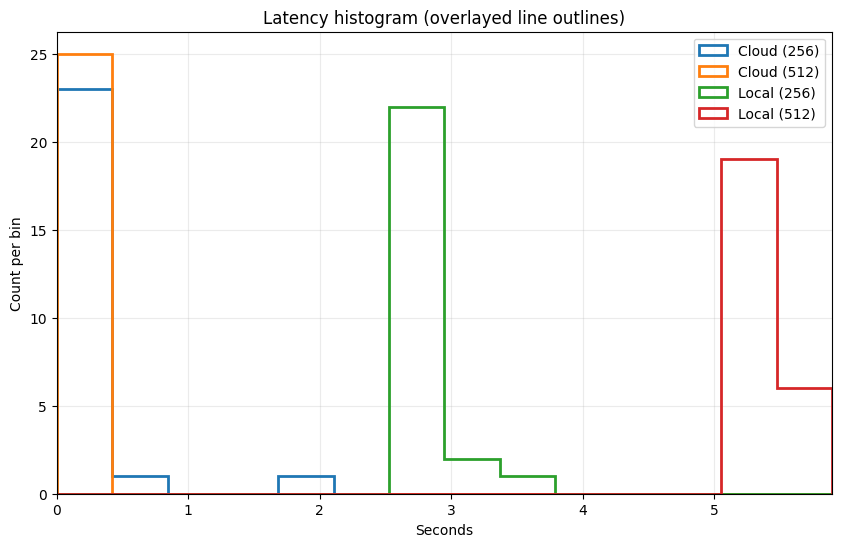

In [ ]:
# Code Generated by GPT-5 (high reasoning) via Windsurf 10/23/25
# Prompt: Thanks, can you add more plots please? I would like the histograms 
# to be one line plot with each line representing a different model and max tokens. 
# I would also like the standard deviation measured.

# More plots: overlay line histogram + std deviation for each series
# Assumes the following lists exist from the benchmark cell:
# cloud_256, cloud_512, loc_256, loc_512

import numpy as np
import statistics as stats
import matplotlib.pyplot as plt

def summarize(times):
    return {
        "avg_s": stats.mean(times),
        "min_s": min(times),
        "max_s": max(times),
        "std_s": stats.stdev(times),  # sample standard deviation
        "n": len(times),
    }

sum_cloud_256 = summarize(cloud_256)
sum_cloud_512 = summarize(cloud_512)
sum_loc_256 = summarize(loc_256)
sum_loc_512 = summarize(loc_512)

print("Summary (seconds):")
print(f"- Cloud 256 -> avg: {sum_cloud_256['avg_s']:.3f}, min: {sum_cloud_256['min_s']:.3f}, max: {sum_cloud_256['max_s']:.3f}, std: {sum_cloud_256['std_s']:.3f}, n={sum_cloud_256['n']}")
print(f"- Cloud 512 -> avg: {sum_cloud_512['avg_s']:.3f}, min: {sum_cloud_512['min_s']:.3f}, max: {sum_cloud_512['max_s']:.3f}, std: {sum_cloud_512['std_s']:.3f}, n={sum_cloud_512['n']}")
print(f"- Local 256 -> avg: {sum_loc_256['avg_s']:.3f}, min: {sum_loc_256['min_s']:.3f}, max: {sum_loc_256['max_s']:.3f}, std: {sum_loc_256['std_s']:.3f}, n={sum_loc_256['n']}")
print(f"- Local 512 -> avg: {sum_loc_512['avg_s']:.3f}, min: {sum_loc_512['min_s']:.3f}, max: {sum_loc_512['max_s']:.3f}, std: {sum_loc_512['std_s']:.3f}, n={sum_loc_512['n']}")

# Overlay line histogram (one plot, one line per series)
all_times = cloud_256 + cloud_512 + loc_256 + loc_512
xmax = max(all_times) * 1.05
bins = np.linspace(0, xmax, 15)  # shared bins

plt.figure(figsize=(10, 6))
plt.hist(cloud_256, bins=bins, histtype='step', linewidth=2, label='Cloud (256)')
plt.hist(cloud_512, bins=bins, histtype='step', linewidth=2, label='Cloud (512)')
plt.hist(loc_256,   bins=bins, histtype='step', linewidth=2, label='Local (256)')
plt.hist(loc_512,   bins=bins, histtype='step', linewidth=2, label='Local (512)')

plt.title("Latency histogram (overlayed line outlines)")
plt.xlabel("Seconds")
plt.ylabel("Count per bin")
plt.xlim(0, xmax)
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()